# Variational Autoencoder

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from torch import nn

## Get the data

In [2]:
data = pd.read_csv('/Users/chriskuo/Downloads/data/age_gender.csv')

## Converting pixels into numpy array
data['pixels']=data['pixels'].apply(lambda x:  np.array(x.split(), dtype="float32"))

data.head()

,age,ethnicity,gender,img_name,pixels
0,1,2,0,20161219203650636.jpg.chip.jpg,"[129.0, 128.0, 128.0, 126.0, 127.0, 130.0, 133..."
1,1,2,0,20161219222752047.jpg.chip.jpg,"[164.0, 74.0, 111.0, 168.0, 169.0, 171.0, 175...."
2,1,2,0,20161219222832191.jpg.chip.jpg,"[67.0, 70.0, 71.0, 70.0, 69.0, 67.0, 70.0, 79...."
3,1,2,0,20161220144911423.jpg.chip.jpg,"[193.0, 197.0, 198.0, 200.0, 199.0, 200.0, 202..."
4,1,2,0,20161220144914327.jpg.chip.jpg,"[202.0, 205.0, 209.0, 210.0, 209.0, 209.0, 210..."


### Randomize the data

In [3]:
data = data.sample(frac=1)

### Splitting train and eval dataframe

In [4]:
train_dataframe = data[:int(0.8*len(data))]
eval_dataframe = data[int(0.8*len(data)):]

## Defines a custom PyTorch Dataset

In [21]:
class MyDataset(Dataset):
    
    def __init__(self, dataframe):
        """
        Initialize the dataset with a pandas DataFrame.

        Args:
            dataframe (pd.DataFrame): DataFrame containing image pixels
                                      and corresponding labels.
        """
        self.dataframe = dataframe

        # Convert image arrays to PyTorch tensors
        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])
        
    def __len__(self):
        """
        Return the total number of samples in the dataset.
        """
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        """
        Retrieve a single sample from the dataset.

        Args:
            idx (int or tensor): Index of the sample.

        Returns:
            dict: Contains image tensor and associated labels.
        """
        
        # Convert tensor index to a Python list if needed
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        # Extract labels from the DataFrame
        age = self.dataframe['age'].iloc[idx]
        ethnicity = self.dataframe['ethnicity'].iloc[idx]
        gender = self.dataframe['gender'].iloc[idx]
        
        # Extract pixel values for the image
        pixels = self.dataframe['pixels'].iloc[idx]

        # Convert pixel list to NumPy array
        pixels = np.array(pixels.tolist())

        # Reshape flattened image into 48x48 format and normalize to [0, 1]
        pixels = pixels.reshape(48, 48) / 255

        # Convert image data to float32 for PyTorch compatibility
        pixels = np.array(pixels, dtype='float32')
        
        # Transform image into a PyTorch tensor
        pixels = self.transform(pixels)
        
        # Create a sample dictionary containing image and labels
        sample = {
            'image': pixels,
            'age': age,
            'ethnicity': ethnicity,
            'gender': gender
        }
        
        return sample

In [22]:
train_dataset = MyDataset(train_dataframe)
eval_dataset = MyDataset(eval_dataframe)

### Creating DataLoaders for Efficient Batch Processing and Model Trainin

In [23]:
# Number of samples processed in each training step
batch_size = 512

# DataLoader for the training set
# - train_dataset: dataset containing training samples
# - batch_size=512: loads 512 samples at a time
# - shuffle=True: randomly shuffles data each epoch to improve model generalization
# - num_workers=0: data loading is performed in the main process
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

# DataLoader for the evaluation/validation set
# - eval_dataset: dataset containing evaluation samples
# - batch_size=512: loads 512 samples at a time
# - shuffle=False: preserves sample order during evaluation
# - num_workers=0: data loading is performed in the main process
eval_dataloader = DataLoader(
    eval_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

## Variational Autoencoder (VAE) Architecture for Image Generation, Reconstruction, and Latent Space Exploration

In [24]:
class VAEmodel(nn.Module):
    def __init__(self, latent_dims, hidden_dims, image_shape):
        super(VAEmodel, self).__init__()
        
        # Dimensionality of the latent vector (compressed representation)
        self.latent_dims = latent_dims
        
        # List containing the number of channels for each hidden layer
        self.hidden_dims = hidden_dims
        
        # Shape of the input image (channels, height, width)
        self.image_shape = image_shape
        
        # Number of channels in the final encoder layer
        self.last_channels = self.hidden_dims[-1]
        
        # Number of input image channels (e.g., 1 for grayscale)
        self.in_channels = self.image_shape[0]

        # Compute the total number of features after all convolutional
        # layers have been flattened
        self.flattened_channels = int(
            self.last_channels *
            (self.image_shape[1] / (2 ** len(self.hidden_dims))) ** 2
        )

        # -------------------------
        # Encoder Construction
        # -------------------------
        # Build a stack of convolutional blocks
        modules = []
        for h_dim in self.hidden_dims:
            modules.append(
                nn.Sequential(
                    # Downsample image using convolution
                    nn.Conv2d(
                        in_channels=self.in_channels,
                        out_channels=h_dim,
                        kernel_size=3,
                        stride=2,
                        padding=1
                    ),
                    # Batch normalization for training stability
                    nn.BatchNorm2d(h_dim),
                    # Nonlinear activation function
                    nn.LeakyReLU()
                )
            )

            self.in_channels = h_dim

        # Combine all encoder layers
        self.encoder = nn.Sequential(*modules)

        # Layers that generate the latent Gaussian distribution parameters
        # Mean (μ)
        self.fc_mu = nn.Linear(self.flattened_channels, latent_dims)

        # Log variance (log σ²)
        self.fc_var = nn.Linear(self.flattened_channels, latent_dims)

        # -------------------------
        # Decoder Input Layer
        # -------------------------
        # Expands latent vector back into flattened feature space
        self.decoder_input = nn.Linear(
            latent_dims,
            self.flattened_channels
        )

        # -------------------------
        # Decoder Construction
        # -------------------------
        # Reverse encoder dimensions to build a symmetric decoder
        self.hidden_dims.reverse()

        modules = []
        for h_dim in self.hidden_dims:
            modules.append(
                nn.Sequential(
                    # Upsample feature maps using transpose convolution
                    nn.ConvTranspose2d(
                        in_channels=self.in_channels,
                        out_channels=h_dim,
                        kernel_size=3,
                        stride=2,
                        padding=1,
                        output_padding=1
                    ),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU()
                )
            )

            self.in_channels = h_dim

        # Combine decoder layers
        self.decoder = nn.Sequential(*modules)

        # -------------------------
        # Output Reconstruction Layer
        # -------------------------
        # Produces reconstructed image with the same shape as input
        self.final_layer = nn.Sequential(
            nn.Conv2d(
                in_channels=self.in_channels,
                out_channels=self.image_shape[0],
                kernel_size=3,
                padding=1
            ),
            # Constrain pixel values to [0,1]
            nn.Sigmoid()
        )

    def get_latent_dims(self):
        """
        Returns the dimensionality of the latent space.
        """
        return self.latent_dims

    def encode(self, input):
        """
        Passes the input image through the encoder and produces
        the latent distribution parameters μ and log(σ²).
        """

        # Extract deep feature representation
        result = self.encoder(input)

        # Flatten feature maps into a vector
        result = torch.flatten(result, start_dim=1)

        # Compute latent distribution mean
        mu = self.fc_mu(result)

        # Compute latent distribution log variance
        log_var = self.fc_var(result)

        return [mu, log_var]

    def decode(self, z):
        """
        Decodes a latent vector z back into image space.
        """

        # Transform latent vector into flattened feature map
        result = self.decoder_input(z)

        # Reshape flattened vector to convolutional feature maps
        result = result.view(
            -1,
            self.last_channels,
            int(self.image_shape[1] / (2 ** len(self.hidden_dims))),
            int(self.image_shape[1] / (2 ** len(self.hidden_dims)))
        )

        # Pass through decoder blocks
        result = self.decoder(result)

        # Produce final reconstructed image
        result = self.final_layer(result)

        return result

    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick:
        z = μ + σ * ε

        Allows gradients to flow through stochastic sampling.
        """

        # Compute standard deviation from log variance
        std = torch.exp(0.5 * log_var)

        # Sample noise from standard normal distribution
        eps = torch.randn_like(std)

        # Generate latent sample
        return mu + eps * std

    def forward(self, input):
        """
        Complete VAE forward pass:
        1. Encode image
        2. Sample latent vector
        3. Decode latent vector
        """

        # Encode image into latent distribution
        mu, log_var = self.encode(input)

        # Sample latent representation
        z = self.reparameterize(mu, log_var)

        # Return reconstruction and latent variables
        return [self.decode(z), input, mu, log_var, z]

    def loss_function(self, recons, input, mu, log_var):
        """
        Computes the Variational Autoencoder loss.

        Total Loss =
            Reconstruction Loss +
            KL Divergence Loss
        """

        # Binary cross-entropy reconstruction loss
        recons_loss = nn.functional.binary_cross_entropy(
            recons.reshape(recons.shape[0], -1),
            input.reshape(input.shape[0], -1),
            reduction="none"
        ).sum(dim=-1)

        # KL divergence between latent distribution and N(0,1)
        kld_loss = -0.5 * torch.sum(
            1 + log_var - mu.pow(2) - log_var.exp(),
            dim=-1
        )

        # Average loss over the batch
        loss = (recons_loss + kld_loss).mean(dim=0)

        return loss

    def sample(self, num_samples, device):
        """
        Generates new images by sampling random points
        from the latent space.
        """

        # Draw latent vectors from standard normal distribution
        z = torch.randn(num_samples, self.latent_dims)

        z = z.to(device)

        # Decode latent vectors into images
        samples = self.decode(z)

        return samples

    def generate(self, x):
        """
        Reconstructs an input image using the VAE.
        """

        return self.forward(x)[0]

    def interpolate(
        self,
        starting_inputs,
        ending_inputs,
        device,
        granularity=10
    ):
        """
        Performs linear interpolation between two images in
        latent space and returns intermediate reconstructions.

        Args:
            starting_inputs: Starting images
            ending_inputs: Ending images
            granularity: Number of interpolation steps

        Returns:
            Sequence of interpolated images
        """

        # Encode start images
        mu, log_var = self.encode(starting_inputs.to(device))
        starting_z = self.reparameterize(mu, log_var)

        # Encode end images
        mu, log_var = self.encode(ending_inputs.to(device))
        ending_z = self.reparameterize(mu, log_var)

        # Interpolation coefficients between 0 and 1
        t = torch.linspace(0, 1, granularity).to(device)

        # Compute linear interpolation in latent space
        intep_line = (
            torch.kron(
                starting_z.reshape(starting_z.shape[0], -1),
                (1 - t).unsqueeze(-1)
            )
            +
            torch.kron(
                ending_z.reshape(ending_z.shape[0], -1),
                t.unsqueeze(-1)
            )
        )

        # Decode interpolated latent vectors
        decoded_line = self.decode(intep_line).reshape(
            (
                starting_inputs.shape[0],
                t.shape[0]
            )
            + (starting_inputs.shape[1:])
        )

        return decoded_line

### Model Initialization and Computing Device Configuration

In [25]:
# Select the device for computation
# - Uses GPU ("cuda") if available for faster training
# - Falls back to CPU if no GPU is detected
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create an instance of the Variational Autoencoder (VAE)
# - latent_dims=20: size of the latent space representation
# - hidden_dims=[32, 64, 64]: number of channels in each encoder/decoder layer
# - image_shape=[1, 48, 48]: input image dimensions
#   (1 channel, 48 pixels height, 48 pixels width)
VAE = VAEmodel(
    latent_dims=20,
    hidden_dims=[32, 64, 64],
    image_shape=[1, 48, 48]
)

# Display the complete model architecture
# This prints all layers, parameters, and network structure
print(VAE)

VAEmodel(
  (encoder): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
  )
  (fc_mu): Linear(in_features=2304, out_features=20, bias=True)
  (fc_var): Linear(in_features=2304, out_features=20, bias=True)
  (decoder_input): Linear(in_features=20, out_features=2304, bias=True)
  (decoder): Sequ

## Visualizing Original Images and VAE Reconstructions

In [26]:
def plot_reconstruction(img, recons):
    """
    Displays a comparison between original images and their
    VAE reconstructions.

    Args:
        img (Tensor): Batch of original images.
        recons (Tensor): Batch of reconstructed images produced
                         by the VAE.
    """

    # Create a figure with 4 rows and 5 columns of subplots
    # Only the first two rows are used here:
    # Row 1 = original images
    # Row 2 = reconstructed images
    fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(10, 5))

    # -------------------------
    # Plot Original Images
    # -------------------------
    for j in range(5):

        # Move tensor to CPU, convert to NumPy array,
        # remove single-channel dimension, and display
        axes[0][j].imshow(
            np.squeeze(img[j].detach().cpu().numpy()),
            cmap='gray'
        )

        # Hide axis ticks and labels
        axes[0][j].axis('off')

    # -------------------------
    # Plot Reconstructed Images
    # -------------------------
    for j in range(5):

        # Display the corresponding reconstructed image
        axes[1][j].imshow(
            np.squeeze(recons[j].detach().cpu().numpy()),
            cmap='gray'
        )

        # Hide axis ticks and labels
        axes[1][j].axis('off')

    # Adjust spacing between subplots for a cleaner layout
    plt.tight_layout(pad=0.)

    # Display the figure
    plt.show()

In [27]:
VAE = VAE.to(device)
VAE.train()

epochs = 3

optimizer = torch.optim.Adam(VAE.parameters(), lr=1e-3)

for epoch in range(epochs):
    
    for batch in train_dataloader:
        
        img = batch['image'].to(device)
        
        optimizer.zero_grad()
        
        recons, input, mu, log_var, _ = VAE.forward(img)
        
        loss = VAE.loss_function(recons, input, mu, log_var)
        
        loss.backward()
        
        optimizer.step()
        
    print(f"Epoch: {epoch+1}         Loss: {loss:.4f}")
    if (epoch+1)%10==0:
        plot_reconstruction(img, recons)

Epoch: 1         Loss: 1444.6943
Epoch: 2         Loss: 1402.0967
Epoch: 3         Loss: 1377.8059


## Generating New Images from the Learned Latent Space

In [28]:
# Set the model to evaluation mode
# This disables training-specific behaviors such as:
# - Dropout (if present)
# - BatchNorm updates to running statistics
# Ensures consistent behavior during inference and image generation
VAE.eval()

# Generate 15 new images by sampling random vectors
# from the learned latent space
#
# - num_samples=15: number of synthetic images to create
# - device=device: generate samples on the selected CPU/GPU
#
# The VAE:
#   1. Draws random latent vectors z ~ N(0,1)
#   2. Passes them through the decoder
#   3. Produces reconstructed image tensors
samples = VAE.sample(
    num_samples=15,
    device=device
)

In [29]:
samples = samples.detach().cpu().numpy()

In [30]:
samples = np.squeeze(samples)

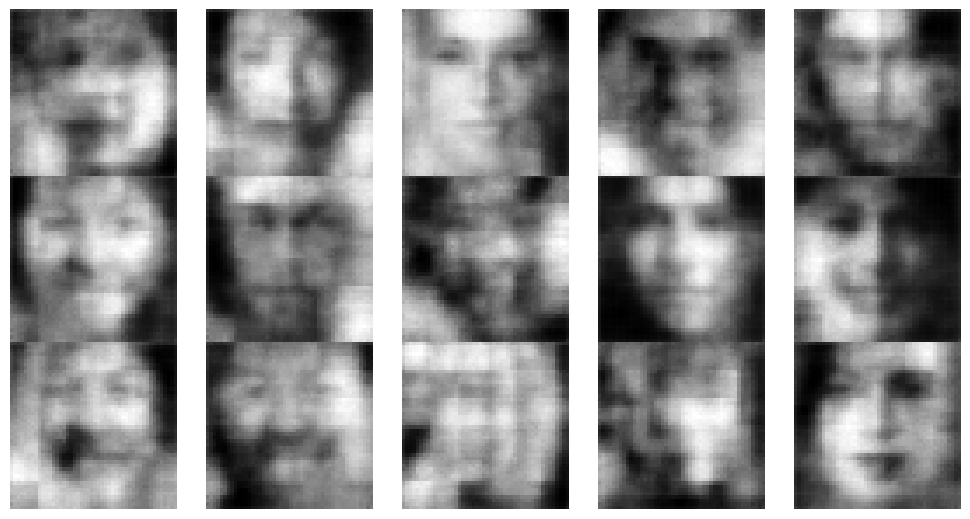

In [31]:
# Display the images generated by the VAE

# Create a 3x5 grid of subplots
# This allows visualization of 15 generated samples
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(10, 5))

# Counter used to access each generated image
k = 0

# Loop through rows
for i in range(3):

    # Loop through columns
    for j in range(5):

        # Display the k-th generated image
        # cmap='gray' ensures grayscale visualization
        axes[i][j].imshow(samples[k], cmap='gray')

        # Remove axis ticks and labels for a cleaner display
        axes[i][j].axis('off')

        # Move to the next generated sample
        k = k + 1

# Adjust spacing between subplots to minimize empty space
plt.tight_layout(pad=0.)

# Render the figure
plt.show()

## Loading and Extracting Evaluation Images for Model Assessment

In [32]:
# Retrieve the first batch from the evaluation DataLoader
# - iter(eval_dataloader) creates an iterator over the evaluation dataset
# - next(...) fetches the first batch of samples
#
# The returned batch is a dictionary containing:
#   'image'      : batch of image tensors
#   'age'        : age labels
#   'ethnicity'  : ethnicity labels
#   'gender'     : gender labels
sample = next(iter(eval_dataloader))

# Extract only the image tensors from the batch
#
# Resulting shape will typically be:
#   [batch_size, 1, 48, 48]
#
# where:
#   batch_size = number of images in the batch
#   1          = grayscale channel
#   48 x 48    = image dimensions
sample_img = sample['image']

In [33]:
# Generate reconstructed versions of the input images
#
# Steps:
# 1. Move the batch of images to the selected device (CPU or GPU)
# 2. Pass the images through the VAE
# 3. The encoder compresses each image into a latent representation
# 4. The decoder reconstructs the images from the latent vectors
#
# Output:
#   recons -> tensor containing reconstructed images
#             with the same shape as the input images
recons = VAE.generate(sample_img.to(device))

In [34]:
# Select a starting index from the batch of evaluation images
# This determines which images will be used for further analysis
# (e.g., reconstruction comparison or latent space interpolation)
index = 0

# Extract the first image from the batch
original_img_1 = sample_img[index]

# Extract the second image from the batch
original_img_2 = sample_img[index + 1]

# Extract the third image from the batch
original_img_3 = sample_img[index + 2]

# Extract the fourth image from the batch
original_img_4 = sample_img[index + 3]

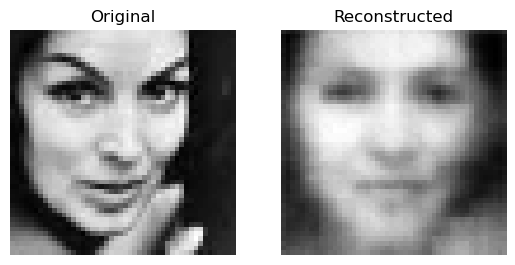

In [35]:
# Create a figure with two subplots arranged side by side
# 121 = 1 row, 2 columns, first subplot
plt.subplot(121)

# Display the original image
# np.squeeze() removes the single channel dimension
# so the image can be displayed correctly by Matplotlib
plt.imshow(np.squeeze(original_img_1), cmap='gray')

# Add a title to identify the image
plt.title('Original')

# Hide axis ticks and labels for a cleaner visualization
plt.axis('off')

# Create the second subplot
# 122 = 1 row, 2 columns, second subplot
plt.subplot(122)

# Display the reconstructed image generated by the VAE
# detach() removes the tensor from the computation graph
# cpu() moves the tensor to CPU memory
# numpy() converts it to a NumPy array for plotting
# np.squeeze() removes the channel dimension
plt.imshow(
    np.squeeze(recons[index].detach().cpu().numpy()),
    cmap='gray'
)

# Add a title to identify the reconstructed image
plt.title('Reconstructed')

# Hide axis ticks and labels
plt.axis('off')

# Display the comparison figure
plt.show()

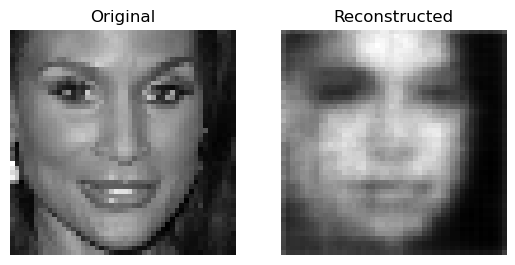

In [36]:
# Create the first subplot (left side)
# Displays the second original image from the batch
plt.subplot(121)

# Remove the channel dimension and display the image in grayscale
plt.imshow(np.squeeze(original_img_2), cmap='gray')

# Add a title to indicate this is the original image
plt.title('Original')

# Hide axis ticks and labels
plt.axis('off')

# Create the second subplot (right side)
# Displays the VAE reconstruction of the same image
plt.subplot(122)

# Convert the reconstructed tensor to a NumPy array for plotting:
# - detach(): removes tensor from computation graph
# - cpu(): moves tensor to CPU memory if needed
# - numpy(): converts tensor to NumPy format
# - squeeze(): removes the single channel dimension
plt.imshow(
    np.squeeze(recons[index + 1].detach().cpu().numpy()),
    cmap='gray'
)

# Add a title to indicate this is the reconstructed image
plt.title('Reconstructed')

# Hide axis ticks and labels
plt.axis('off')

# Display both images side by side for comparison
plt.show()

## Latent Space Interpolation Between Two Images

In [37]:
# Add a batch dimension to the selected images
#
# Each image originally has shape:
#   [1, 48, 48]
#
# unsqueeze(0) adds a new dimension at position 0,
# resulting in:
#   [1, 1, 48, 48]
#
# This is required because the VAE expects input in the form:
#   [batch_size, channels, height, width]
starting_inputs = original_img_1.unsqueeze(0)
ending_inputs = original_img_2.unsqueeze(0)

# Number of intermediate steps to generate between the
# starting and ending images in latent space
#
# granularity = 10 means:
# - image 1 = starting image
# - image 10 = ending image
# - images in between are smooth transitions
granularity = 10

# Perform latent space interpolation between the two images
#
# Steps:
# 1. Encode both images into latent vectors
# 2. Generate evenly spaced latent representations
#    between the two vectors
# 3. Decode each latent representation back into image space
# 4. Return a sequence of gradually changing images
#
# squeeze() removes dimensions of size 1 from the output
# to make visualization easier
interpolation = VAE.interpolate(
    starting_inputs=starting_inputs,
    ending_inputs=ending_inputs,
    device=device,
    granularity=granularity
).squeeze()

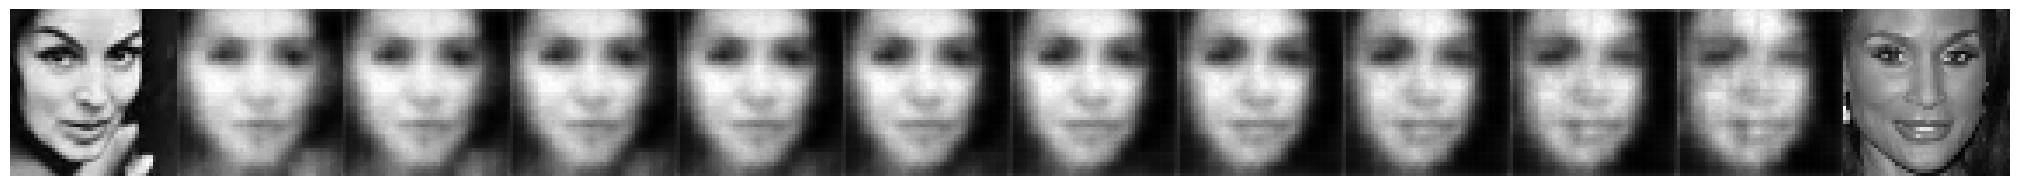

In [38]:
# Create a single row of subplots to visualize the interpolation sequence
#
# Number of columns:
# - 1 for the starting image
# - granularity for the interpolated images
# - 1 for the ending image
#
# Example:
# If granularity = 10, then total columns = 12
fig, axes = plt.subplots(
    nrows=1,
    ncols=granularity + 2,
    figsize=(20, 5)
)

# Display the interpolated images
#
# axes[1] through axes[granularity] are reserved
# for the intermediate latent-space transitions
for j in range(granularity):

    # Convert tensor to NumPy array and display in grayscale
    axes[j + 1].imshow(
        np.squeeze(interpolation[j].detach().cpu().numpy()),
        cmap='gray'
    )

    # Hide axis ticks and labels
    axes[j + 1].axis('off')

# Display the starting image in the first subplot
axes[0].imshow(
    np.squeeze(original_img_1),
    cmap='gray'
)
axes[0].axis('off')

# Display the ending image in the last subplot
axes[granularity + 1].imshow(
    np.squeeze(original_img_2),
    cmap='gray'
)
axes[granularity + 1].axis('off')

# Adjust spacing between images to create a seamless visualization
plt.tight_layout(pad=0.)

# Render the figure
plt.show()

## Extracting and Analyzing Latent Representations from the Training Dataset

In [39]:
# Initialize a list to store the latent representations (z vectors)
# for all images in the training dataset
total_z = []

# Iterate through every sample in the training dataset
for train_sample in train_dataset:

    # Extract the image and move it to the selected device (CPU/GPU)
    img = train_sample['image'].to(device)

    # Add a batch dimension and pass the image through the VAE
    #
    # Forward output:
    # [reconstructed_image, input_image, mu, log_var, z]
    #
    # We only need the latent vector z here
    _, _, _, _, z = VAE.forward(img.unsqueeze(0))

    # Remove extra dimensions from the latent vector
    # Detach it from the computation graph
    # Move it to CPU
    # Convert it to a NumPy array
    z = z.squeeze().detach().cpu().numpy()

    # Store the latent representation
    total_z.append(z)

# Convert the list of latent vectors into a NumPy array
#
# Resulting shape:
#   [number_of_images, latent_dims]
#
# Example:
#   (23705, 20)
# where:
#   23705 = number of training images
#   20    = latent space dimension
total_z = np.array(total_z)

In [40]:
# Compute the maximum value for each latent dimension
#
# axis=0 means the operation is performed column-wise:
# - Each column corresponds to one latent feature
# - The result contains the largest value observed for each
#   latent dimension across all training samples
#
# Example:
# If total_z has shape (23705, 20),
# max_z will have shape (20,)
max_z = total_z.max(axis=0)

# Compute the minimum value for each latent dimension
#
# axis=0 performs the operation independently for each
# latent feature (column)
#
# The result contains the smallest value observed for each
# latent dimension across the entire training dataset
#
# Example:
# If total_z has shape (23705, 20),
# min_z will have shape (20,)
min_z = total_z.min(axis=0)


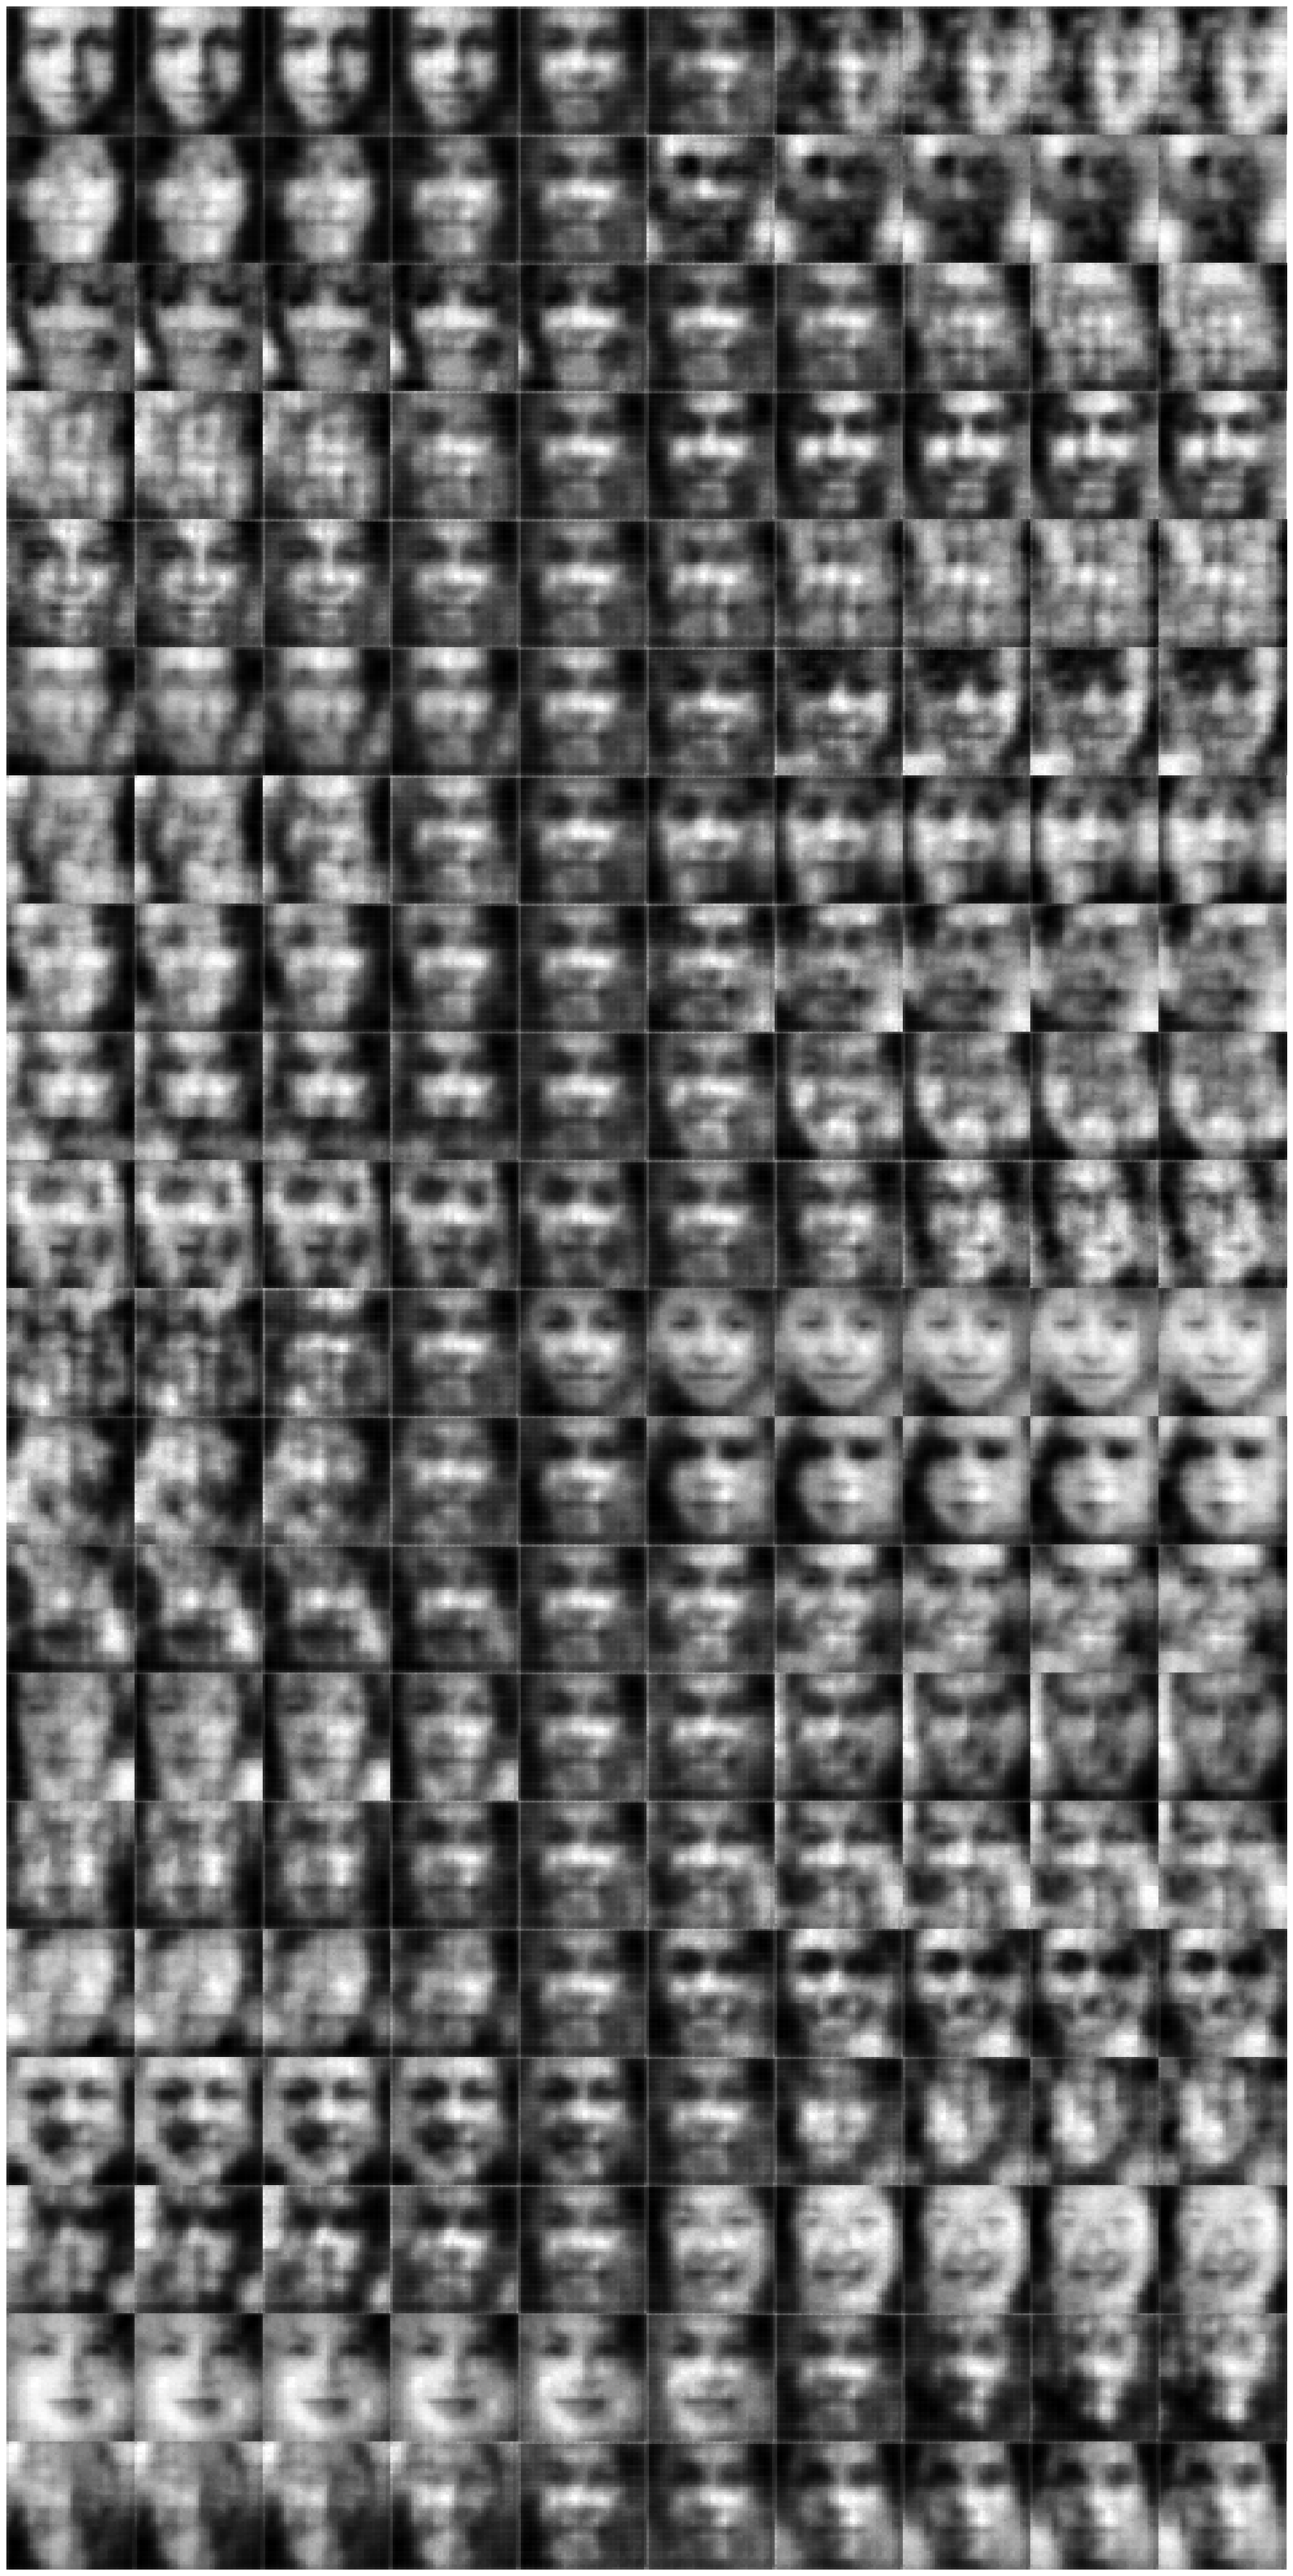

In [41]:
# Number of values to sample across each latent dimension
# Higher values create smoother transitions but produce more images
granularity = 10

# Get the dimensionality of the VAE latent space
#
# Example:
# If latent_dims = 20, the VAE represents each image
# using a 20-dimensional latent vector
latent_space_dims = VAE.get_latent_dims()

# Create a visualization grid:
# - Rows represent different latent dimensions
# - Columns represent different values sampled within that dimension
#
# Example:
# 20 latent dimensions × 10 sampled values
fig, axes = plt.subplots(
    nrows=latent_space_dims,
    ncols=granularity,
    figsize=(20, 40)
)

# Iterate through each latent dimension
for i in range(latent_space_dims):

    # Generate evenly spaced values between the minimum and
    # maximum observed values for the current latent dimension
    #
    # These values will be used to explore how changing this
    # specific latent feature affects the generated image
    t = torch.linspace(
        min_z[i],
        max_z[i],
        granularity
    ).to(device)

    # Initialize a latent vector with all dimensions set to zero
    #
    # Shape:
    # [1, latent_space_dims]
    z = torch.zeros([1, latent_space_dims]).to(device)

    # Loop through the sampled values for the current dimension
    for j, y in enumerate(t):

        # Modify only the current latent dimension
        # All other dimensions remain fixed at zero
        z[0][i] = y

        # Decode the latent vector into an image
        imgs_decoded = VAE.decode(z).squeeze()

        # Display the generated image
        axes[i][j].imshow(
            imgs_decoded.detach().cpu().numpy(),
            cmap='gray'
        )

        # Remove axis labels and ticks for cleaner visualization
        axes[i][j].axis('Off')

# Reduce spacing between subplots
plt.tight_layout(pad=0.)

# Display the latent space traversal visualization
plt.show()